# 02 — Feature Engineering
**Project:** Paper.id Fraud Detection
**Goal:** Membangun fitur-fitur yang relevan untuk deteksi fraud, lalu export ke `data/processed/`.

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
from src.data.loader import load_all
from src.data.cleaner import clean_all
from src.features.engineering import build_features

data   = load_all()
data   = clean_all(data)
transactions = build_features(data['transactions'])
company      = data['company']

print('Shape setelah feature engineering:', transactions.shape)
print('Kolom baru:')
print([c for c in transactions.columns if c not in [
    'dpt_id','buyer_id','seller_id','transaction_amount',
    'payment_method_name','payment_provider_name',
    'transaction_created_datetime','transaction_updated_datetime','dpt_promotion_id'
]])

Shape setelah feature engineering: (50000, 27)
Kolom baru:
['is_outlier_iqr', 'anomaly', 'is_self_transaction', 'transaction_count', 'relationship_score_z', 'relationship_anomaly', 'time_diff_minutes', 'is_burst', 'is_unusual_gap', 'burst_intensity', 'promo_usage_count_buyer', 'promo_usage_count_seller', 'promo_exploit_z_buyer', 'promo_exploit_buyer', 'promo_exploit_z_seller', 'promo_exploit_seller', 'transaction_amount_scaled', 'time_diff_minutes_zscore']


## 1. Buyer-Seller Relationship Score

In [3]:
print(transactions[['transaction_count', 'relationship_score_z', 'relationship_anomaly']].describe())
print(f"\nJumlah pasangan anomali: {transactions['relationship_anomaly'].sum()}")
print(f"Persentase            : {transactions['relationship_anomaly'].mean()*100:.2f}%")

       transaction_count  relationship_score_z  relationship_anomaly
count       50000.000000          5.000000e+04          50000.000000
mean           68.352080         -1.534772e-17              0.025320
std           202.684052          1.000000e+00              0.157097
min             1.000000         -3.323008e-01              0.000000
25%             4.000000         -3.174995e-01              0.000000
50%            12.000000         -2.780292e-01              0.000000
75%            41.000000         -1.349493e-01              0.000000
max          1266.000000          5.908940e+00              1.000000

Jumlah pasangan anomali: 1266
Persentase            : 2.53%


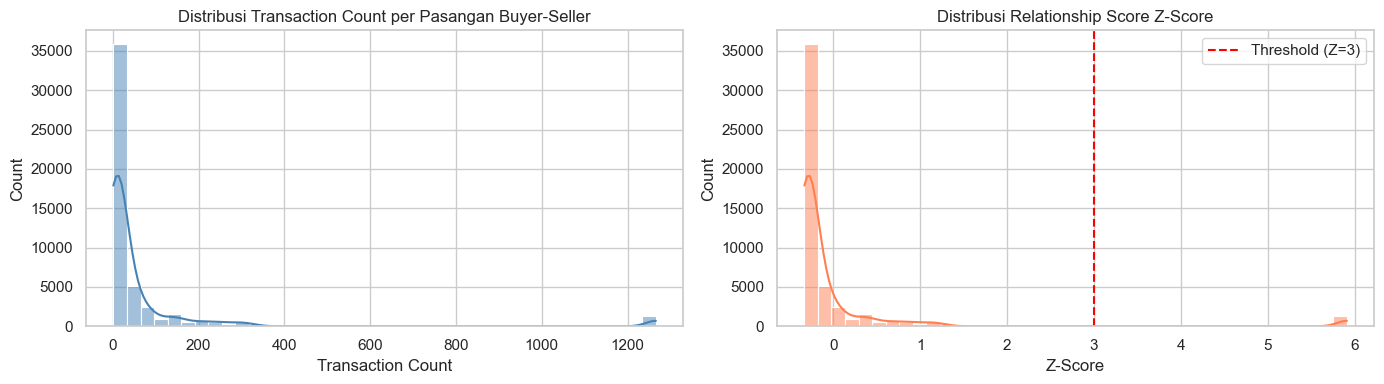

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(transactions['transaction_count'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Transaction Count per Pasangan Buyer-Seller')
axes[0].set_xlabel('Transaction Count')

sns.histplot(transactions['relationship_score_z'], bins=40, kde=True, ax=axes[1], color='coral')
axes[1].axvline(x=3, color='red', linestyle='--', label='Threshold (Z=3)')
axes[1].set_title('Distribusi Relationship Score Z-Score')
axes[1].set_xlabel('Z-Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig_relationship_score.png', dpi=150)
plt.show()

In [5]:
print('Top 10 pasangan anomali:')
anomali_pairs = transactions[transactions['relationship_anomaly'] == 1]
anomali_pairs.groupby(['buyer_id','seller_id'])['transaction_count'].first().sort_values(ascending=False).head(10)

Top 10 pasangan anomali:


buyer_id                                                          seller_id                                                       
0bb440f2ae8461ca7b424f9b0efddbb2a1993e07a6d629a5b9f82f5818264d1b  0bb440f2ae8461ca7b424f9b0efddbb2a1993e07a6d629a5b9f82f5818264d1b    1266
Name: transaction_count, dtype: int64

## 2. Transaction Frequency Metrics

In [6]:
print('Burst transactions :', transactions['is_burst'].sum())
print('Unusual gaps       :', transactions['is_unusual_gap'].sum())
print(f"Burst rate         : {transactions['is_burst'].mean()*100:.2f}%")
print(f"Gap rate           : {transactions['is_unusual_gap'].mean()*100:.2f}%")

Burst transactions : 14292
Unusual gaps       : 1244
Burst rate         : 28.58%
Gap rate           : 2.49%


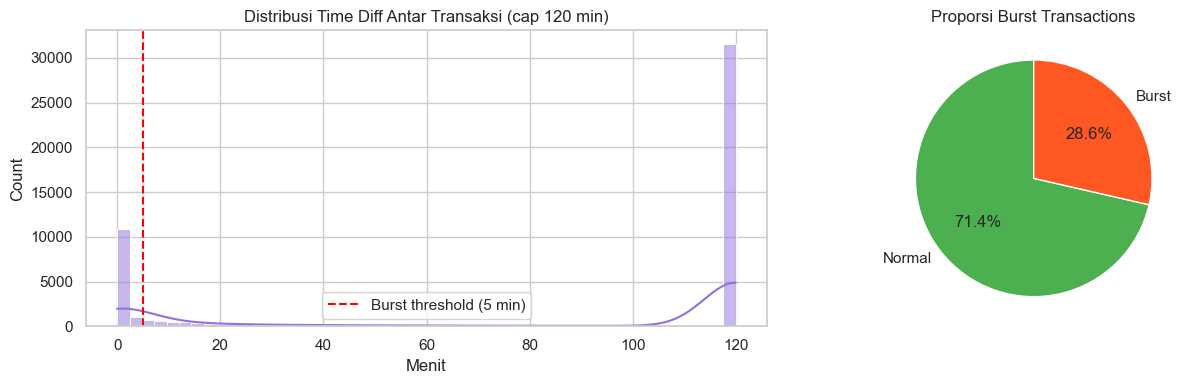

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribusi time diff (cap 120 menit untuk readability)
td = transactions['time_diff_minutes'].clip(upper=120)
sns.histplot(td, bins=50, kde=True, ax=axes[0], color='mediumpurple')
axes[0].axvline(x=5, color='red', linestyle='--', label='Burst threshold (5 min)')
axes[0].set_title('Distribusi Time Diff Antar Transaksi (cap 120 min)')
axes[0].set_xlabel('Menit')
axes[0].legend()

# Burst vs normal
burst_counts = transactions['is_burst'].value_counts()
axes[1].pie(burst_counts, labels=['Normal', 'Burst'], autopct='%1.1f%%',
            colors=['#4CAF50', '#FF5722'], startangle=90)
axes[1].set_title('Proporsi Burst Transactions')

plt.tight_layout()
plt.savefig('../reports/fig_transaction_frequency.png', dpi=150)
plt.show()

## 3. Promotion Exploitation Indicator

In [8]:
print('Eksploitasi promosi oleh buyer :', transactions['promo_exploit_buyer'].sum())
print('Eksploitasi promosi oleh seller:', transactions['promo_exploit_seller'].sum())

Eksploitasi promosi oleh buyer : 1266
Eksploitasi promosi oleh seller: 0


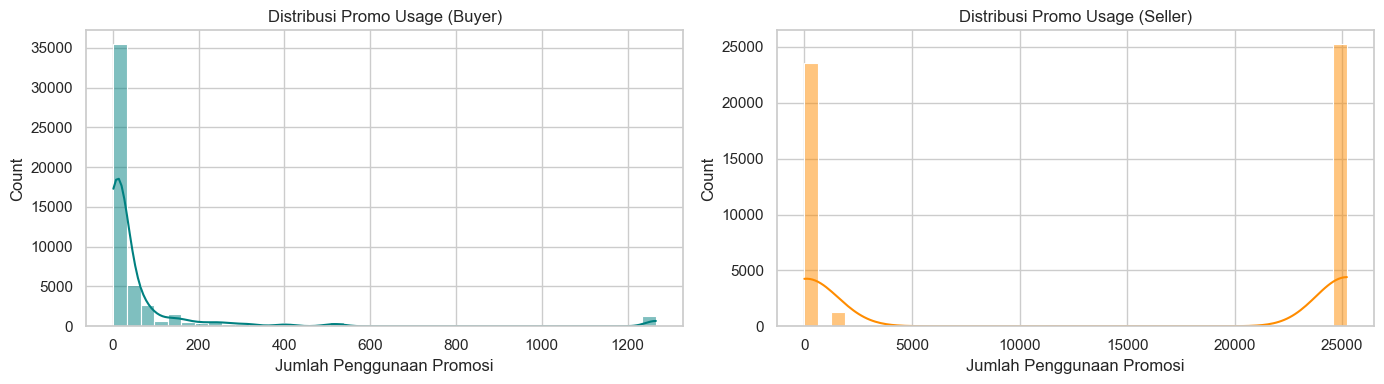

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title, color in [
    (axes[0], 'promo_usage_count_buyer',  'Distribusi Promo Usage (Buyer)',  'teal'),
    (axes[1], 'promo_usage_count_seller', 'Distribusi Promo Usage (Seller)', 'darkorange'),
]:
    data_plot = transactions[col].clip(upper=transactions[col].quantile(0.99))
    sns.histplot(data_plot, bins=40, kde=True, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Jumlah Penggunaan Promosi')

plt.tight_layout()
plt.savefig('../reports/fig_promo_exploitation.png', dpi=150)
plt.show()

## 4. Korelasi Antar Fitur

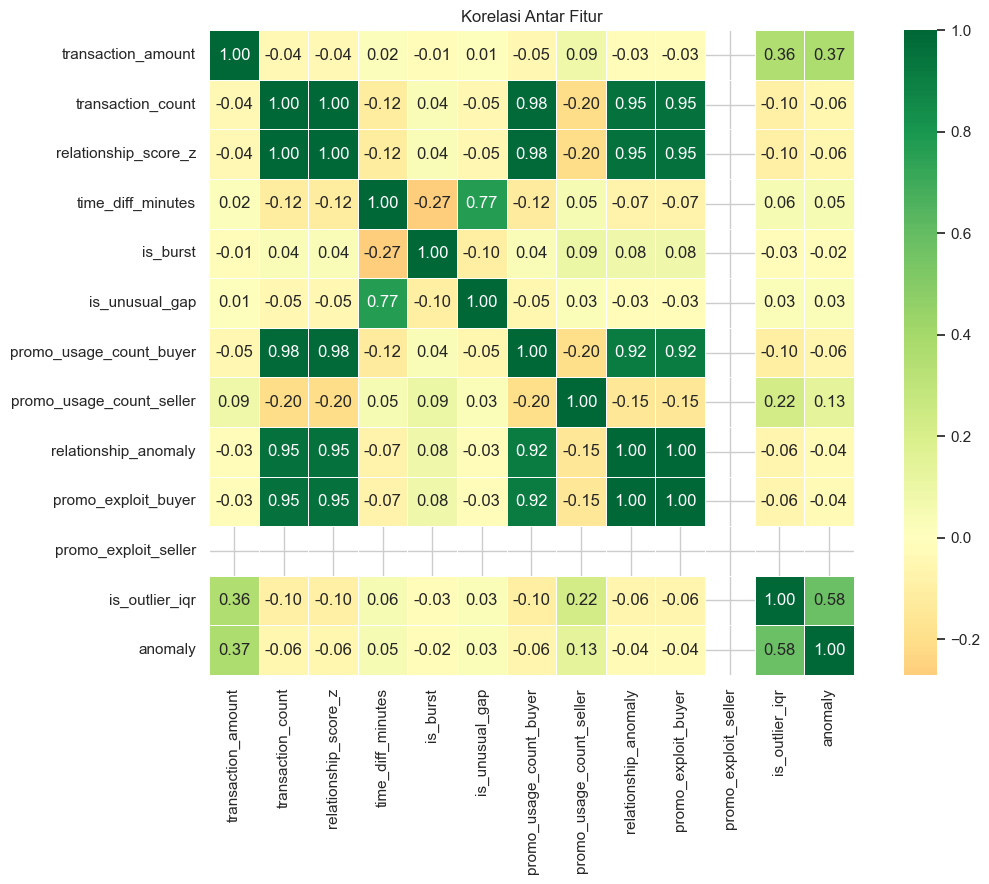

In [10]:
feature_cols = [
    'transaction_amount', 'transaction_count', 'relationship_score_z',
    'time_diff_minutes', 'is_burst', 'is_unusual_gap',
    'promo_usage_count_buyer', 'promo_usage_count_seller',
    'relationship_anomaly', 'promo_exploit_buyer', 'promo_exploit_seller',
    'is_outlier_iqr', 'anomaly'
]

corr = transactions[feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('../reports/fig_feature_correlation.png', dpi=150)
plt.show()

## 5. Gabungkan dengan Company (Fraud Labels)

In [11]:
# FIX: Gunakan .map() bukan .merge() untuk hindari row explosion
company_clean   = company.drop_duplicates(subset=['company_id'])
company_indexed = company_clean.set_index('company_id')

cols_to_map = [
    'user_fraud_flag', 'blacklist_account_flag',
    'company_kyc_status_name', 'company_kyb_status_name', 'company_age_days'
]

for col in cols_to_map:
    transactions[f'buyer_{col}']  = transactions['buyer_id'].map(company_indexed[col])
    transactions[f'seller_{col}'] = transactions['seller_id'].map(company_indexed[col])

# FIX: is_self_transaction TIDAK masuk label fraud (artifact, bukan fraud asli)
# is_self_transaction tetap sebagai fitur tambahan untuk model
transactions['is_fraud'] = (
    (transactions['buyer_user_fraud_flag']         == 1) |
    (transactions['seller_user_fraud_flag']        == 1) |
    (transactions['buyer_blacklist_account_flag']  == 1) |
    (transactions['seller_blacklist_account_flag'] == 1)
).astype(int)

# FIX: Exclude self-transaction dari dataset training
n_before = len(transactions)
transactions_model = transactions[transactions['is_self_transaction'] == 0].copy()
n_after = len(transactions_model)

print(f'Rows sebelum filter self-transaction : {n_before:,}')
print(f'Rows setelah filter                  : {n_after:,}')
print(f'Rows dibuang                         : {n_before - n_after:,}')
print(f'\nFraud transactions : {transactions_model["is_fraud"].sum():,}')
print(f'Fraud rate         : {transactions_model["is_fraud"].mean()*100:.2f}%')
print(f'\nBreakdown sumber fraud:')
print(f'  buyer_fraud_flag   : {(transactions_model["buyer_user_fraud_flag"]==1).sum():,}')
print(f'  seller_fraud_flag  : {(transactions_model["seller_user_fraud_flag"]==1).sum():,}')
print(f'  buyer_blacklist    : {(transactions_model["buyer_blacklist_account_flag"]==1).sum():,}')
print(f'  seller_blacklist   : {(transactions_model["seller_blacklist_account_flag"]==1).sum():,}')


Rows sebelum filter self-transaction : 50,000
Rows setelah filter                  : 26,772
Rows dibuang                         : 23,228

Fraud transactions : 4,633
Fraud rate         : 17.31%

Breakdown sumber fraud:
  buyer_fraud_flag   : 4,565
  seller_fraud_flag  : 40
  buyer_blacklist    : 4,603
  seller_blacklist   : 40


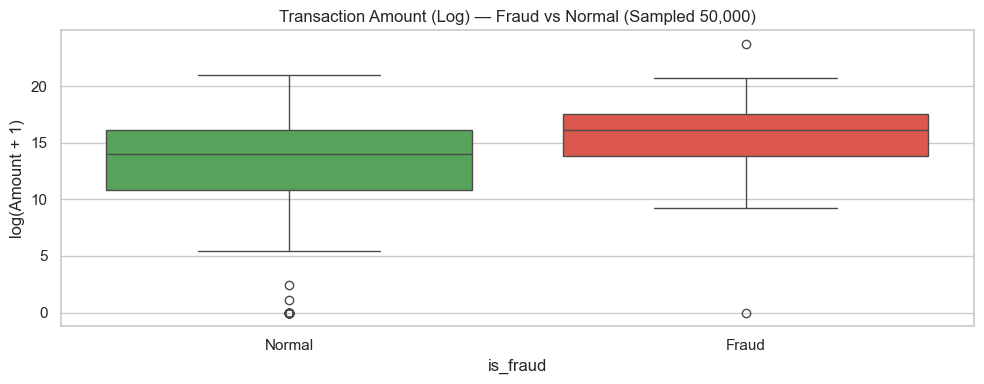

In [12]:
# 1. Ambil sampel data agar menghemat RAM saat plotting
# Gunakan min() untuk menyesuaikan dengan ukuran dataset
sample_size = min(100000, len(transactions))
df_sample = transactions.sample(n=sample_size, random_state=42)

# 2. Distribusi amount: fraud vs normal menggunakan data sampel
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df_sample,
    x='is_fraud',
    y=np.log1p(df_sample['transaction_amount']),
    palette={'0': '#4CAF50', '1': '#F44336'}
)
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.title(f'Transaction Amount (Log) — Fraud vs Normal (Sampled {sample_size:,})')
plt.ylabel('log(Amount + 1)')
plt.tight_layout()
plt.savefig('../reports/fig_fraud_vs_normal_amount.png', dpi=150)
plt.show()

## 6. Export ke data/processed/

In [13]:
from pathlib import Path

PROCESSED_DIR = Path('..') / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Export transactions_model (sudah exclude self-transaction) sebagai input modeling
transactions_model.to_csv(PROCESSED_DIR / 'transactions_featured.csv', index=False)

# Export buyer-seller summary untuk Tableau
buyer_seller_summary = (
    transactions_model.groupby(['buyer_id', 'seller_id'])
    .agg(
        transaction_count    = ('dpt_id', 'count'),
        total_amount         = ('transaction_amount', 'sum'),
        avg_amount           = ('transaction_amount', 'mean'),
        burst_count          = ('is_burst', 'sum'),
        fraud_count          = ('is_fraud', 'sum'),
        relationship_score_z = ('relationship_score_z', 'first'),
        relationship_anomaly = ('relationship_anomaly', 'first'),
    )
    .reset_index()
)
buyer_seller_summary.to_csv(PROCESSED_DIR / 'buyer_seller_network.csv', index=False)

# Export full transactions (include self-transaction) untuk Tableau — untuk analisis terpisah
transactions.to_csv(PROCESSED_DIR / 'transactions_all.csv', index=False)

print('Export selesai:')
for f in sorted(PROCESSED_DIR.iterdir()):
    print(f'  {f.name:<35} {f.stat().st_size / 1024:.1f} KB')


Export selesai:
  buyer_seller_network.csv            1210.4 KB
  transactions_all.csv                26945.2 KB
  transactions_featured.csv           14400.5 KB
